# Building Age Classification from Satellite Imagery

# Notebook 4 — Modelling & Evaluation

---

**Approach: Metric Learning**

In this notebook we will use a **metric learning** approach to the classification problem. This involves learning a feature representation where
buildings of the same age class cluster together, regardless of which city they come from. 

In practice this means:
1. **Train on Madrid** (the labelled city) using cross-validation to get reliable performance
   estimates with error bars.
2. **Zero-shot transfer** — apply the Madrid model directly to Amsterdam, with no Amsterdam
   labels, to measure the baseline domain gap.
3. **Few-shot prototype transfer** — given a small number of labelled Amsterdam examples,
   compute per-class prototype vectors (class means in feature space) and classify by
   nearest prototype. This is the inference step of prototype networks, a standard
   metric learning technique.

The few-shot experiment shows how much label budget is needed to close the Madrid–Amsterdam gap.

For more information on the metric learning approach, please see the supportind document "METRIC_LEARNING_APPROACH.md"

**NOTE**:  Metric learning is _one possible approach_.  Feel free to try another approach!

## 4.1 Setup & Imports

In [43]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

CLASS_COLORS = {1: '#4393c3', 2: '#2ca25f', 3: '#fd8d3c', 4: '#de2d26'}
CLASS_LABELS_MADRID    = {1: 'Pre-1960',  2: '1960-1984', 3: '1984-2004', 4: '2004-2024'}
CLASS_LABELS_AMSTERDAM = {1: 'Pre-1945',  2: '1945-1984', 3: '1984-2004', 4: '2004-2024'}

plt.rcParams['figure.dpi'] = 100
print("Setup complete.")


Setup complete.


## 4.2 Load Preprocessed Data

In [44]:
with open('../data/preprocessed/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_madrid    = data['X_madrid']
y_madrid    = data['y_madrid']
X_amsterdam = data['X_amsterdam']
y_amsterdam = data['y_amsterdam']
feature_names = data['feature_names']
pixel_ids_madrid    = data['pixel_ids_madrid']     # (N, 2)  px_key, py_key
pixel_ids_amsterdam = data['pixel_ids_amsterdam']  # (N, 2)  px_key, py_key

print(f'Madrid:    {X_madrid.shape}  ({len(np.unique(y_madrid))} classes)')
print(f'Amsterdam: {X_amsterdam.shape}  ({len(np.unique(y_amsterdam))} classes)')
print(f'Features:  {len(feature_names)}')
print()
for name, y, labels in [('Madrid', y_madrid, CLASS_LABELS_MADRID),
                         ('Amsterdam', y_amsterdam, CLASS_LABELS_AMSTERDAM)]:
    print(f'{name} class distribution:')
    for cls in sorted(np.unique(y)):
        n = (y == cls).sum()
        print(f'  Class {cls} ({labels[cls]}): {n:,}  ({n/len(y)*100:.1f}%)')
    print()


Madrid:    (76263, 60)  (4 classes)
Amsterdam: (25992, 60)  (4 classes)
Features:  60

Madrid class distribution:
  Class 1 (Pre-1960): 13,794  (18.1%)
  Class 2 (1960-1984): 27,152  (35.6%)
  Class 3 (1984-2004): 18,672  (24.5%)
  Class 4 (2004-2024): 16,645  (21.8%)

Amsterdam class distribution:
  Class 1 (Pre-1945): 7,568  (29.1%)
  Class 2 (1945-1984): 8,802  (33.9%)
  Class 3 (1984-2004): 6,745  (26.0%)
  Class 4 (2004-2024): 2,877  (11.1%)



---

## 4.3 Cross-Validation on Madrid

### What is a fold?

The training data is randomly divided into **k equal parts** called folds. The model is
trained on k-1 folds and evaluated on the remaining 1 fold. This is repeated k times,
rotating which fold is held out each time, so every sample is evaluated exactly once.
The result is k performance scores, one per fold.

### What is a repeat?

A **repeat** runs the entire k-fold process again with a fresh random split of the data
into folds. The second repeat produces k more scores that are independent of the first
repeat (different samples end up in different folds). With r repeats you collect k x r
scores in total.

### Why repeats matter for variance estimation

The k scores within a single repeat are **not independent** — every pair of folds shares
(k-2)/k of their training data. This correlation means the empirical standard deviation
of k scores underestimates the true run-to-run variance. A single 5-fold run gives only
5 correlated numbers, which is a very noisy basis for a variance estimate.

Adding repeats breaks this correlation: scores from different repeats are independent
because the splits are drawn fresh each time. Even 5 repeats (25 scores total) gives a
much more reliable standard deviation than a single 5-fold run.

### Configuration

Set `N_FOLDS, N_REPEATS` below. The default `5, 1` reproduces standard 5-fold CV.
Increase repeats (e.g. `10, 5`) for a more reliable variance estimate at the cost of
additional training time — each repeat requires k more model fits.

In [45]:
from sklearn.model_selection import RepeatedStratifiedKFold

# ── Configuration: set both values here ───────────────────────────────────────
N_FOLDS, N_REPEATS = 5, 5
# ─────────────────────────────────────────────────────────────────────────────

RF_PARAMS   = dict(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
total_fits  = N_FOLDS * N_REPEATS
rskf        = RepeatedStratifiedKFold(n_splits=N_FOLDS, n_repeats=N_REPEATS, random_state=42)

all_f1      = []
oof_true    = []
oof_pred    = []
oof_proba   = []   # predict_proba output for each held-out pixel
oof_indices = []   # original row index of each held-out pixel

print(f'{N_FOLDS}-fold x {N_REPEATS}-repeat CV on Madrid  ({total_fits} model fits)')
print('-' * 55)

for fit_num, (tr_idx, val_idx) in enumerate(rskf.split(X_madrid, y_madrid), 1):
    X_tr, X_val = X_madrid[tr_idx], X_madrid[val_idx]
    y_tr, y_val = y_madrid[tr_idx], y_madrid[val_idx]

    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X_tr, y_tr)
    y_pred  = rf.predict(X_val)
    y_proba = rf.predict_proba(X_val)

    oof_true.extend(y_val.tolist())
    oof_pred.extend(y_pred.tolist())
    oof_proba.extend(y_proba.tolist())
    oof_indices.extend(val_idx.tolist())

    f1 = f1_score(y_val, y_pred, average='macro')
    all_f1.append(f1)
    print(f'  Fit {fit_num:3d}/{total_fits}: macro-F1 = {f1:.4f}')

print('-' * 55)
print(f'  Mean macro F1: {np.mean(all_f1):.4f} +/- {np.std(all_f1):.4f}')

fold_f1     = all_f1
oof_true    = np.array(oof_true)
oof_pred    = np.array(oof_pred)
oof_proba   = np.array(oof_proba)
oof_indices = np.array(oof_indices)


5-fold x 5-repeat CV on Madrid  (25 model fits)
-------------------------------------------------------
  Fit   1/25: macro-F1 = 0.6171
  Fit   2/25: macro-F1 = 0.6249
  Fit   3/25: macro-F1 = 0.6182
  Fit   4/25: macro-F1 = 0.6202
  Fit   5/25: macro-F1 = 0.6118
  Fit   6/25: macro-F1 = 0.6136
  Fit   7/25: macro-F1 = 0.6225
  Fit   8/25: macro-F1 = 0.6261
  Fit   9/25: macro-F1 = 0.6158
  Fit  10/25: macro-F1 = 0.6101
  Fit  11/25: macro-F1 = 0.6106
  Fit  12/25: macro-F1 = 0.6234
  Fit  13/25: macro-F1 = 0.6142
  Fit  14/25: macro-F1 = 0.6210
  Fit  15/25: macro-F1 = 0.6179
  Fit  16/25: macro-F1 = 0.6254
  Fit  17/25: macro-F1 = 0.6176
  Fit  18/25: macro-F1 = 0.6150
  Fit  19/25: macro-F1 = 0.6201
  Fit  20/25: macro-F1 = 0.6150
  Fit  21/25: macro-F1 = 0.6198
  Fit  22/25: macro-F1 = 0.6170
  Fit  23/25: macro-F1 = 0.6198
  Fit  24/25: macro-F1 = 0.6153
  Fit  25/25: macro-F1 = 0.6154
-------------------------------------------------------
  Mean macro F1: 0.6179 +/- 0.0043


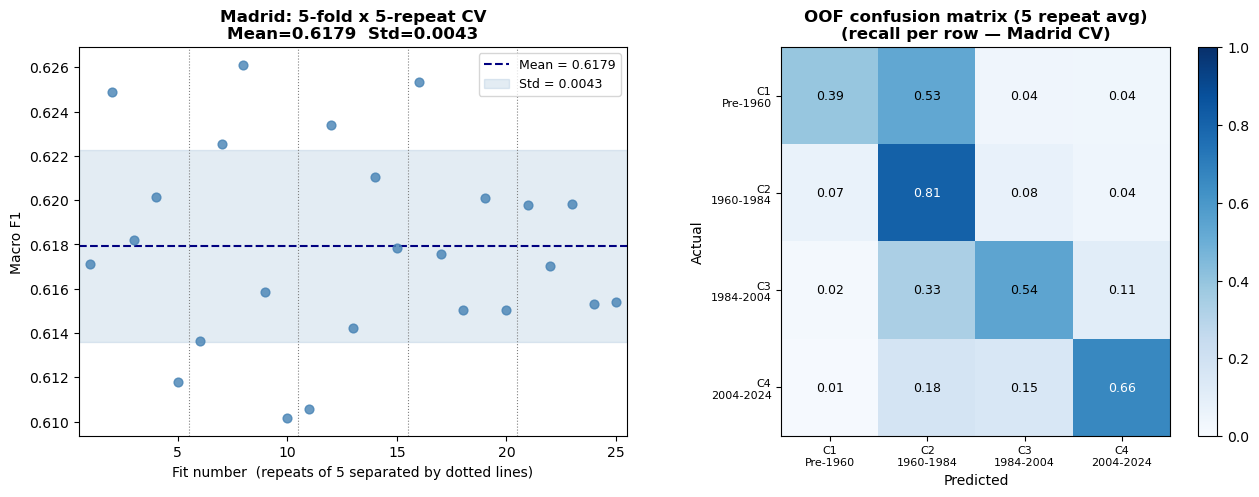

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: individual scores + mean/std band
ax   = axes[0]
xs   = np.arange(1, total_fits + 1)
mn   = np.mean(all_f1)
sd   = np.std(all_f1)

ax.scatter(xs, all_f1, color='steelblue', s=40, zorder=3, alpha=0.8)
ax.axhline(mn, color='navy', linewidth=1.5, linestyle='--', label=f'Mean = {mn:.4f}')
ax.fill_between([0.5, total_fits + 0.5], mn - sd, mn + sd,
                color='steelblue', alpha=0.15, label=f'Std = {sd:.4f}')

# Mark repeat boundaries
if N_REPEATS > 1:
    for r in range(1, N_REPEATS):
        ax.axvline(r * N_FOLDS + 0.5, color='grey', linewidth=0.8, linestyle=':')
    ax.set_xlabel(f'Fit number  (repeats of {N_FOLDS} separated by dotted lines)')
else:
    ax.set_xlabel('Fold')

ax.set_ylabel('Macro F1')
ax.set_title(f'Madrid: {N_FOLDS}-fold x {N_REPEATS}-repeat CV\n'
             f'Mean={mn:.4f}  Std={sd:.4f}', fontweight='bold')
ax.set_xlim(0.5, total_fits + 0.5)
ax.legend(fontsize=9)

# Right: out-of-fold confusion matrix (accumulated over all folds x repeats)
ax = axes[1]
classes_mad = sorted(np.unique(oof_true))
cm_oof  = confusion_matrix(oof_true, oof_pred, labels=classes_mad)
cm_norm = cm_oof.astype(float) / cm_oof.sum(axis=1, keepdims=True)
xlbls   = [f'C{c}\n{CLASS_LABELS_MADRID[c]}' for c in classes_mad]
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(classes_mad))); ax.set_xticklabels(xlbls, fontsize=8)
ax.set_yticks(range(len(classes_mad))); ax.set_yticklabels(xlbls, fontsize=8)
for i in range(len(classes_mad)):
    for j in range(len(classes_mad)):
        v = cm_norm[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if v > 0.6 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
title_suffix = f'({N_REPEATS} repeat avg)' if N_REPEATS > 1 else ''
ax.set_title(f'OOF confusion matrix {title_suffix}\n(recall per row — Madrid CV)',
             fontweight='bold')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


We see that the macro F1 determination is accurate to within roughly plus or minus 0.01. The confusion matrix shows that Classes 2 and 4 acheive higher recall than the other classes.  We also see that Class 2 is over-predicted.  For example, mmost instances of class 1 are predicted as class 2. This is a strong indication that the class imbalance is biasing prediction towards class 2, which is hte largest class.

---

## 4.3a  Spatial Uncertainty Mapping

### `predict_proba` and per-pixel confidence

`RandomForestClassifier.predict_proba(X)` returns a **probability vector** $(p_1, p_2, p_3, p_4)$ for each pixel, where $p_k$ is the fraction of trees in the forest that voted for class $k$.  These values sum to 1, and the hard label produced by `predict()` is simply $\arg\max_k p_k$.

Using `predict_proba` gives a richer picture than a single label: a pixel with probabilities $(0.90, 0.05, 0.03, 0.02)$ is confidently assigned to class 1, while $(0.30, 0.28, 0.25, 0.17)$ is a near-random guess that happens to land on class 1.  The two pixels look identical in a confusion matrix but carry very different levels of certainty.

### Mapping uncertainty across the city

We use `predict_proba` to study the **geographical distribution of uncertainty** — where in the city is the model confident, and where is it unsure?  Mapping uncertainty back onto the building grid can reveal:

- Clusters of uncertain pixels along age-class boundaries or in mixed-use districts
- Areas where the domain gap (Madrid→Amsterdam) inflates uncertainty systematically
- Neighbourhoods where targeted labelling would most improve performance

Two complementary measures are shown for each city:

| Measure | Formula | Interpretation |
|---------|---------|----------------|
| **Shannon entropy** | $H = -\sum_k p_k \log_2 p_k$ (bits) | Ranges from 0 (all probability on one class) to 2 bits (uniform over 4 classes).  High = uncertain classifier. |
| **KL from true class** | $D = -\log_2 p_{\text{true}}$ (bits) | The KL divergence of the predicted distribution from the true one-hot distribution simplifies to the negative log-probability of the correct class.  **0 = model was certain and correct; high = wrong or uncertain.**  Colour scale is inverted so bright = accurate. |

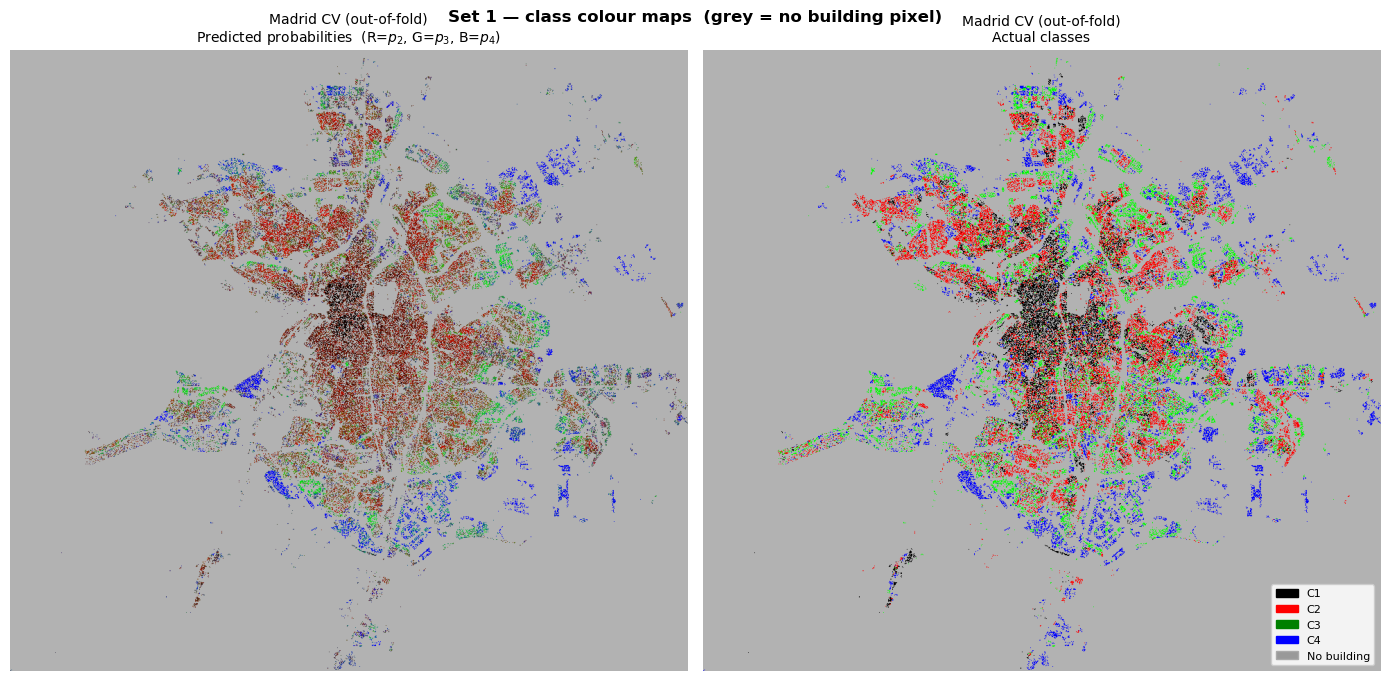

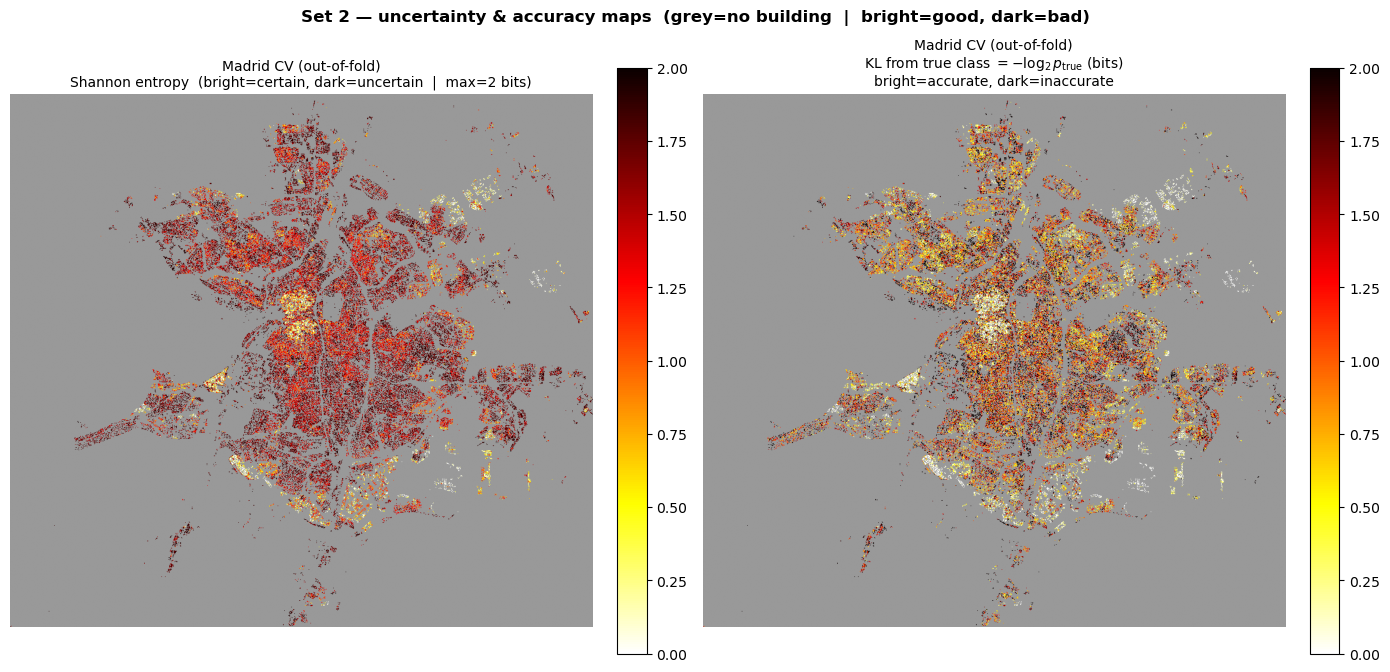

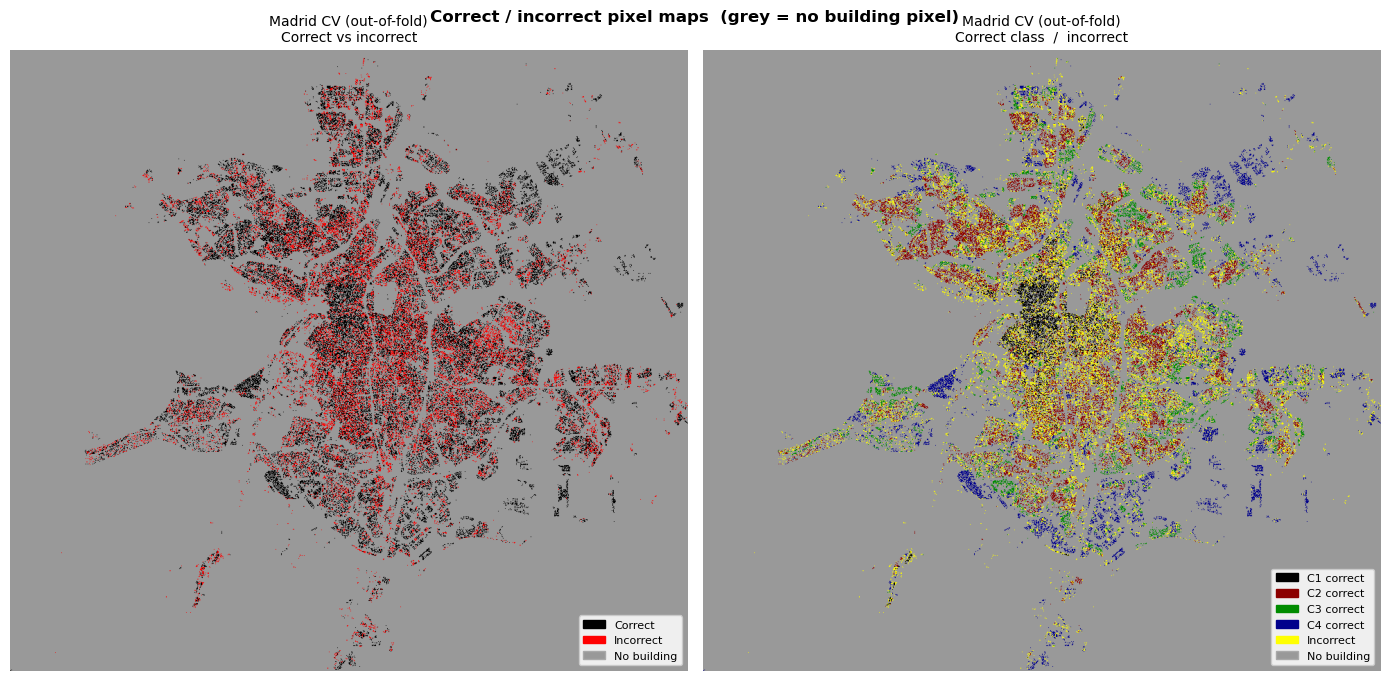

In [47]:
import matplotlib.patches as mpatches

_GREY    = (0.6, 0.6, 0.6)
_NO_BLDG = mpatches.Patch(facecolor=_GREY, edgecolor='darkgrey', label='No building')


def make_pixel_grid(pixel_ids, values, fill_value):
    """Place per-pixel values into a 2-D spatial image using (px_key, py_key) coordinates.
    values: (N,) scalar or (N, C) multi-channel array.
    fill_value: value for grid positions with no building pixel.
    """
    px = pixel_ids[:, 0].astype(int);  px -= px.min()
    py = pixel_ids[:, 1].astype(int);  py -= py.min()
    H, W = py.max() + 1, px.max() + 1
    if values.ndim == 1:
        img = np.full((H, W), fill_value, dtype=np.float32)
        img[py, px] = values
    else:
        img = np.full((H, W, values.shape[1]), fill_value, dtype=np.float32)
        img[py, px] = values
    return img


def spatial_uncertainty_plots(pixel_ids, proba, y_true, title_prefix=''):
    """
    Set 1 (grey background):
        Left : RGB image where R=p2*256, G=p3*256, B=p4*256
        Right: actual class colours  (C1=black, C2=red, C3=green, C4=blue)
    Set 2 (hot_r — bright=good, dark=bad):
        Left : Shannon entropy in bits  (bright=certain, dark=uncertain)
        Right: KL(true||pred) = -log2(p_true_class)  (bright=accurate, dark=inaccurate)
    """
    eps = 1e-10

    # ── Set 1: colour images ──────────────────────────────────────────────────
    rgb_vals = (np.floor(proba[:, 1:] * 256).clip(0, 255) / 255.0).astype(np.float32)
    rgb_img  = make_pixel_grid(pixel_ids, rgb_vals, fill_value=0.70)

    _class_rgb = np.array([[0,0,0],[1,0,0],[0,1,0],[0,0,1]], dtype=np.float32)
    cls_img    = make_pixel_grid(pixel_ids, _class_rgb[y_true - 1], fill_value=0.7)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(rgb_img);  axes[0].axis('off')
    axes[0].set_title(f'{title_prefix}\nPredicted probabilities  '
                      r'(R=$p_2$, G=$p_3$, B=$p_4$)', fontsize=10)

    axes[1].imshow(cls_img);  axes[1].axis('off')
    axes[1].set_title(f'{title_prefix}\nActual classes', fontsize=10)
    axes[1].legend(handles=[
        mpatches.Patch(color='black', label='C1'),
        mpatches.Patch(color='red',   label='C2'),
        mpatches.Patch(color='green', label='C3'),
        mpatches.Patch(color='blue',  label='C4'),
        _NO_BLDG,
    ], loc='lower right', fontsize=8, framealpha=0.85)

    plt.suptitle('Set 1 — class colour maps  (grey = no building pixel)',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Set 2: uncertainty / accuracy maps ────────────────────────────────────
    H_vals           = -(proba * np.log2(proba + eps)).sum(axis=1)
    true_class_proba = proba[np.arange(len(y_true)), y_true - 1]
    kl_vals          = -np.log2(true_class_proba + eps)

    H_img  = make_pixel_grid(pixel_ids, H_vals.astype(np.float32),  fill_value=np.nan)
    kl_img = make_pixel_grid(pixel_ids, kl_vals.astype(np.float32), fill_value=np.nan)

    cmap_h  = plt.cm.hot_r.copy(); cmap_h.set_bad(_GREY)
    cmap_kl = plt.cm.hot_r.copy(); cmap_kl.set_bad(_GREY)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    im0 = axes[0].imshow(H_img, cmap=cmap_h, vmin=0, vmax=2)
    axes[0].axis('off')
    axes[0].set_title(f'{title_prefix}\nShannon entropy  '
                      '(bright=certain, dark=uncertain  |  max=2 bits)', fontsize=10)
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(kl_img, cmap=cmap_kl, vmin=0, vmax=2)
    axes[1].axis('off')
    axes[1].set_title(f'{title_prefix}\n'
                      r'KL from true class $= -\log_2 p_{\rm true}$ (bits)'
                      '\nbright=accurate, dark=inaccurate', fontsize=10)
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.suptitle('Set 2 — uncertainty & accuracy maps  '
                 '(grey=no building  |  bright=good, dark=bad)', fontweight='bold')
    plt.tight_layout()
    plt.show()


def spatial_accuracy_plots(pixel_ids, y_true, y_pred, title_prefix=''):
    """
    Plot 1: black=correct, red=incorrect.
    Plot 2: C1=black, C2=mid-dark red, C3=mid-dark green, C4=mid-dark blue, incorrect=yellow.
    Grey background on both.
    """
    correct = (y_true == y_pred)

    p1_vals = np.where(
        correct[:, None],
        np.array([[0, 0, 0]], dtype=np.float32),
        np.array([[1, 0, 0]], dtype=np.float32),
    )
    p1_img = make_pixel_grid(pixel_ids, p1_vals, fill_value=0.6)

    correct_colors = np.array([
        [  0,   0,   0],
        [140,   0,   0],
        [  0, 140,   0],
        [  0,   0, 140],
    ], dtype=np.float32) / 255.0
    yellow  = np.array([[1, 1, 0]], dtype=np.float32)
    p2_vals = np.where(correct[:, None], correct_colors[y_true - 1], yellow)
    p2_img  = make_pixel_grid(pixel_ids, p2_vals.astype(np.float32), fill_value=0.6)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(p1_img);  axes[0].axis('off')
    axes[0].set_title(f'{title_prefix}\nCorrect vs incorrect', fontsize=10)
    axes[0].legend(handles=[
        mpatches.Patch(color='black', label='Correct'),
        mpatches.Patch(color='red',   label='Incorrect'),
        _NO_BLDG,
    ], loc='lower right', fontsize=8, framealpha=0.85)

    axes[1].imshow(p2_img);  axes[1].axis('off')
    axes[1].set_title(f'{title_prefix}\nCorrect class  /  incorrect', fontsize=10)
    axes[1].legend(handles=[
        mpatches.Patch(color='black',                      label='C1 correct'),
        mpatches.Patch(color=(140/255, 0,       0      ),  label='C2 correct'),
        mpatches.Patch(color=(0,       140/255, 0      ),  label='C3 correct'),
        mpatches.Patch(color=(0,       0,       140/255),  label='C4 correct'),
        mpatches.Patch(color='yellow',                     label='Incorrect'),
        _NO_BLDG,
    ], loc='lower right', fontsize=8, framealpha=0.85)

    plt.suptitle('Correct / incorrect pixel maps  (grey = no building pixel)',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── Madrid OOF ────────────────────────────────────────────────────────────────
pixel_ids_oof = pixel_ids_madrid[oof_indices]
spatial_uncertainty_plots(pixel_ids_oof, oof_proba, oof_true,
                          title_prefix='Madrid CV (out-of-fold)')
spatial_accuracy_plots(pixel_ids_oof, oof_true, oof_pred,
                       title_prefix='Madrid CV (out-of-fold)')


We can see that despite the relatively low accuracy rates, the algorithm seems to be correctly identifying the major local areas where each class dominates. this suggests that a subsequent ML algorithm that acts on the soft-probabiliy output image may acheive improved accuracy.

---

## 4.4 Final Model: Train on All Madrid Data

After cross-validation has confirmed the performance estimate, we train a final model on
the complete Madrid dataset. This maximises the information available and produces the
model used for Amsterdam transfer.

In this notebook we have not taken class imbalance into account.  When class imbalance is present, larger classes tend to be overpredicted, because a randomly-chosen datapoint has a larger probability of being in the larger class. in your model you may wish to take this into account.

**NOTE**: In this notebook, we use random forest as a baseline, with no parameter optimization. Your job is to improve on this baseline.  Be creative--try other techniques.

In [48]:
print('Training final Random Forest on all Madrid data...')
rf_final = RandomForestClassifier(**RF_PARAMS)
rf_final.fit(X_madrid, y_madrid)
print('Done.')

# In-sample check (should be ~1.0; confirms the model is fitted)
y_mad_pred = rf_final.predict(X_madrid)
print(f'In-sample accuracy: {accuracy_score(y_madrid, y_mad_pred):.4f}  '
      f'(expected ~1.0 for RF with no max_depth limit)')


Training final Random Forest on all Madrid data...
Done.
In-sample accuracy: 1.0000  (expected ~1.0 for RF with no max_depth limit)


---

## 4.5 Feature Importance

Random Forest feature importance (mean decrease in impurity) shows which temporal
statistics are most useful for distinguishing age classes. Temporal features should
rank highly if the time-series approach is capturing meaningful signals.

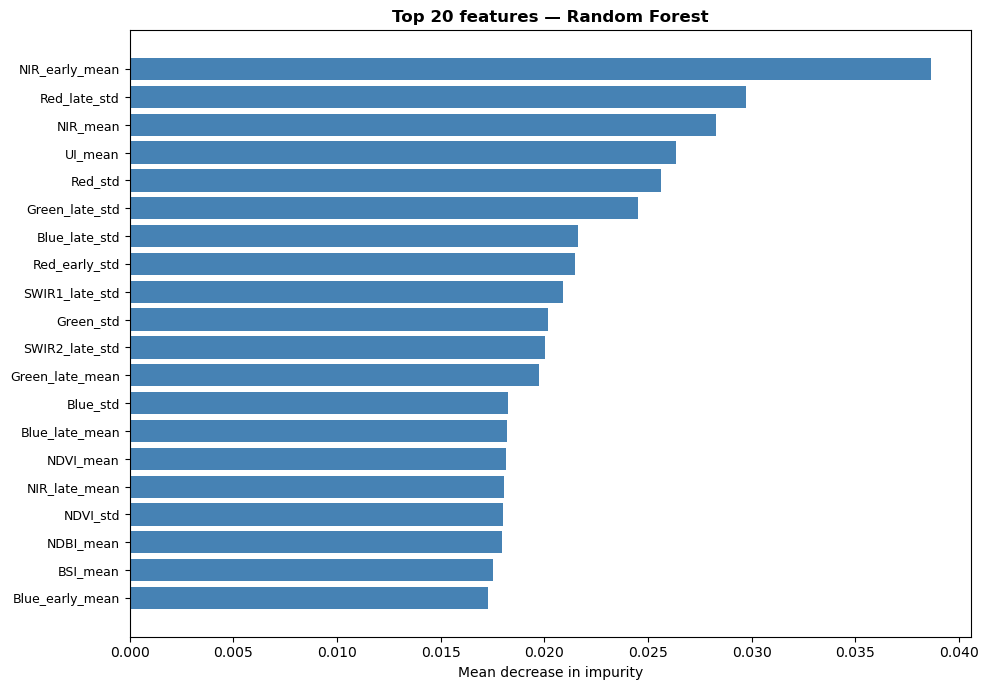

Top 10 features:
   1. NIR_early_mean: 0.0387
   2. Red_late_std: 0.0297
   3. NIR_mean: 0.0283
   4. UI_mean: 0.0264
   5. Red_std: 0.0256
   6. Green_late_std: 0.0245
   7. Blue_late_std: 0.0216
   8. Red_early_std: 0.0215
   9. SWIR1_late_std: 0.0209
  10. Green_std: 0.0202


In [49]:
importances = rf_final.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

TOP_N = 20
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(TOP_N),
        importances[sorted_idx[:TOP_N]][::-1],
        color='steelblue', edgecolor='none')
ax.set_yticks(range(TOP_N))
ax.set_yticklabels([feature_names[i] for i in sorted_idx[:TOP_N]][::-1], fontsize=9)
ax.set_xlabel('Mean decrease in impurity')
ax.set_title(f'Top {TOP_N} features — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for rank, idx in enumerate(sorted_idx[:10]):
    print(f'  {rank+1:2d}. {feature_names[idx]}: {importances[idx]:.4f}')


We see that a large number of features are nearly equal in importance. This is no doubt at least partially due to the high correlation between features.   But it also indicates that the Random Forest may be able to discern differencfes based on complex relationships, that would be difficult for a human to discern.

---

## 4.6 Zero-Shot Transfer to Amsterdam

We apply the Madrid-trained model to all Amsterdam pixels without using any Amsterdam labels.
This establishes the **baseline domain gap**: how much performance we lose when moving to
a city the model has never seen.

In [50]:
y_ams_pred_zero = rf_final.predict(X_amsterdam)

f1_zero = f1_score(y_amsterdam, y_ams_pred_zero, average='macro')
print('Zero-shot transfer to Amsterdam (no Amsterdam labels):')
print(f'  Macro F1: {f1_zero:.4f}')
print()
classes_ams = sorted(np.unique(y_amsterdam))
print(classification_report(
    y_amsterdam, y_ams_pred_zero,
    labels=classes_ams,
    target_names=[f'Class {c}' for c in classes_ams],
    digits=4,
))


Zero-shot transfer to Amsterdam (no Amsterdam labels):
  Macro F1: 0.3427

              precision    recall  f1-score   support

     Class 1     0.4279    0.1016    0.1642      7568
     Class 2     0.3661    0.8804    0.5171      8802
     Class 3     0.7527    0.1051    0.1845      6745
     Class 4     0.6007    0.4355    0.5049      2877

    accuracy                         0.4032     25992
   macro avg     0.5368    0.3807    0.3427     25992
weighted avg     0.5104    0.4032    0.3267     25992



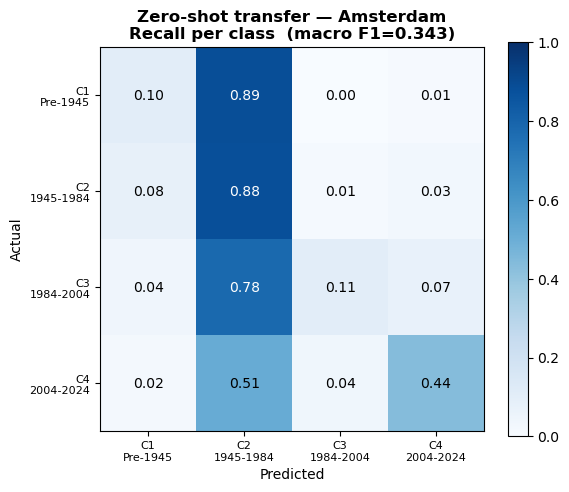

In [51]:
cm_zero = confusion_matrix(y_amsterdam, y_ams_pred_zero,
                           labels=sorted(np.unique(y_amsterdam)))
cm_norm_zero = cm_zero.astype(float) / cm_zero.sum(axis=1, keepdims=True)
xlbls_ams = [f'C{c}\n{CLASS_LABELS_AMSTERDAM[c]}' for c in sorted(np.unique(y_amsterdam))]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm_zero, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(xlbls_ams))); ax.set_xticklabels(xlbls_ams, fontsize=8)
ax.set_yticks(range(len(xlbls_ams))); ax.set_yticklabels(xlbls_ams, fontsize=8)
for i in range(len(xlbls_ams)):
    for j in range(len(xlbls_ams)):
        v = cm_norm_zero[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                color='white' if v > 0.6 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Zero-shot transfer — Amsterdam\nRecall per class  (macro F1={f1_zero:.3f})',
             fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


Accuracy is poor for the zero-shot model.  this is to be expected, because buildings in Amsterdam have quite different characteristics from buildings in Madrid. The purpose of the few-shot retraining is to identify Amsterdam-specific clusters within the same metric space. The Amsterdam pixels are then assigned to these recalculated clusters. 

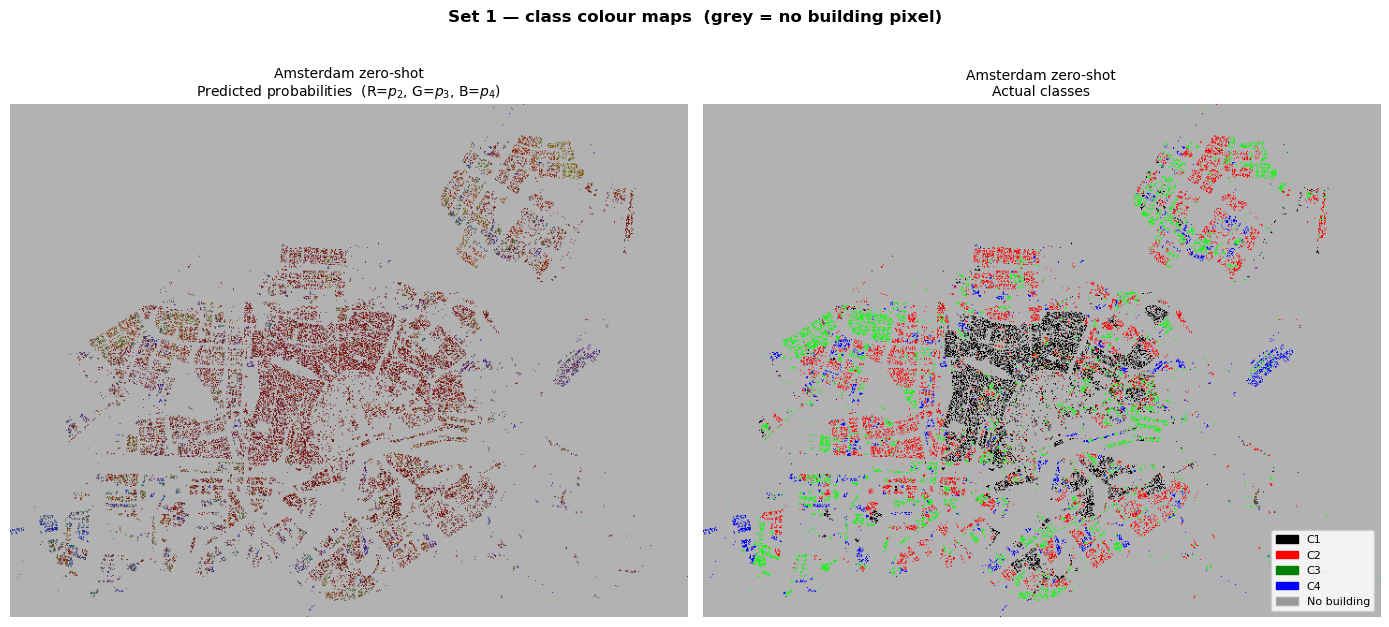

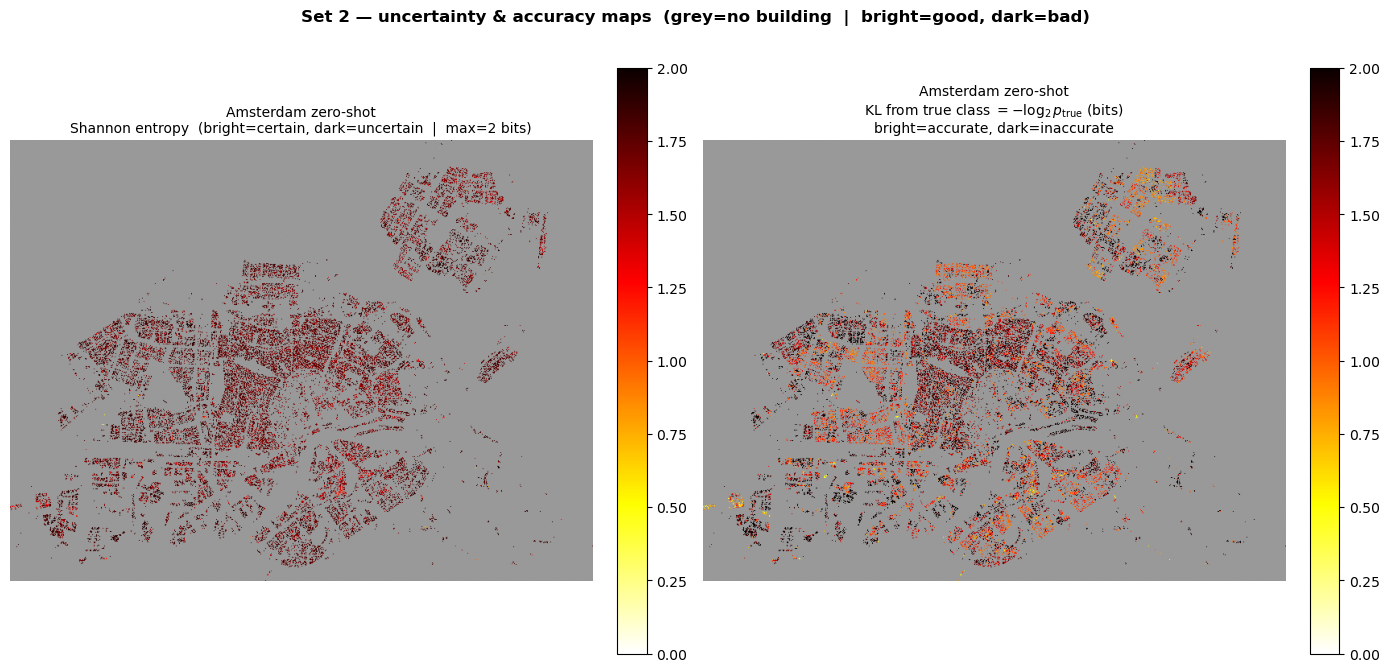

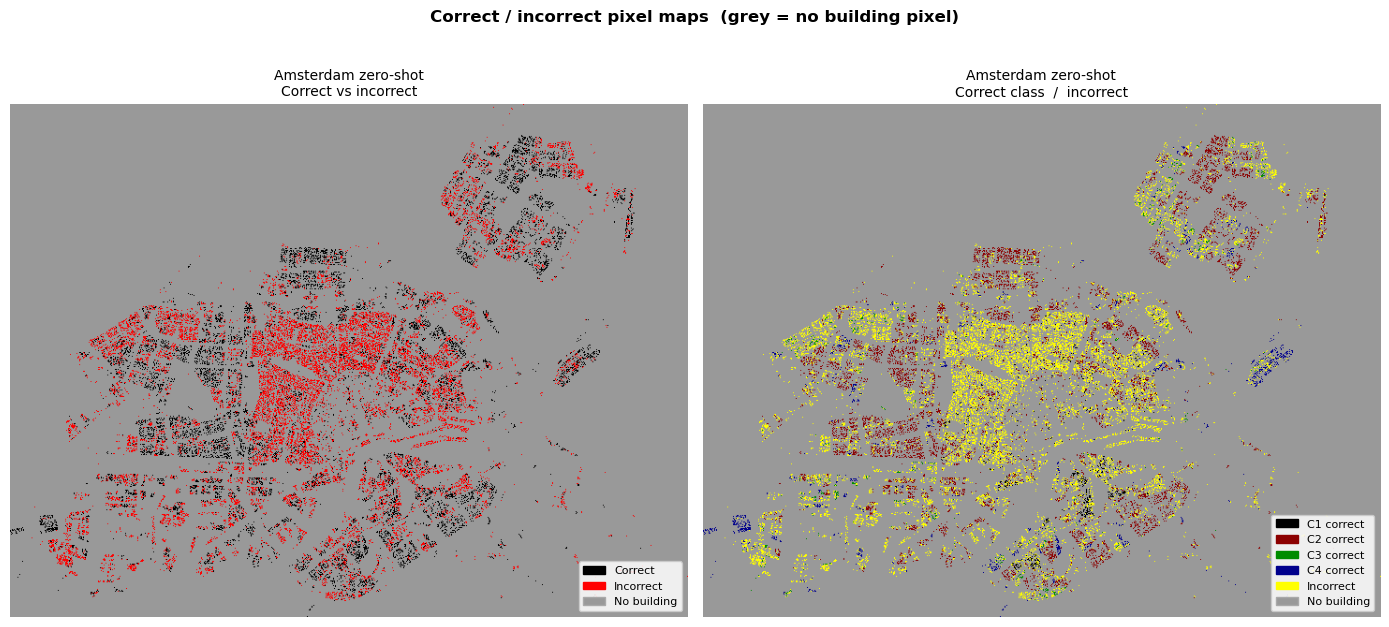

In [52]:
# Amsterdam zero-shot — predict_proba from the Madrid-trained final model
proba_amsterdam_zero = rf_final.predict_proba(X_amsterdam)
spatial_uncertainty_plots(pixel_ids_amsterdam, proba_amsterdam_zero, y_amsterdam,
                          title_prefix='Amsterdam zero-shot')
spatial_accuracy_plots(pixel_ids_amsterdam, y_amsterdam, y_ams_pred_zero,
                       title_prefix='Amsterdam zero-shot')


The graphs show clearly that Class 2 is being wildly overpredicted in the zero-shot model.

---

## 4.7 Few-Shot Prototype Transfer

The prototype classifier is the inference step of **prototype networks**, a standard
metric learning technique:

1. For each class, compute the **prototype** = mean feature vector of the labelled examples.
2. Classify unlabelled points by assigning them to the nearest prototype (Euclidean distance).

This is equivalent to 1-NN where the single "neighbour" is a smoothed class representative.
It generalises better than raw k-NN with very few labels because averaging reduces noise.

We run the experiment for several label budgets (samples per class) and repeat each
10 times with different random draws to estimate variance. The resulting plot shows
performance as a function of label budget — the key question for deciding how much
annotation effort Amsterdam requires.

In [53]:
def prototype_predict(X_support, y_support, X_query):
    classes    = np.unique(y_support)
    prototypes = np.stack([X_support[y_support == c].mean(axis=0) for c in classes])
    dists      = np.linalg.norm(X_query[:, None, :] - prototypes[None, :, :], axis=2)
    return classes[dists.argmin(axis=1)]

SHOTS_PER_CLASS = [5, 10, 25, 50, 100, 200]
N_TRIALS        = 10
rng             = np.random.default_rng(42)
classes_ams     = np.unique(y_amsterdam)

proto_results = {n: [] for n in SHOTS_PER_CLASS}

for n_shots in SHOTS_PER_CLASS:
    for _ in range(N_TRIALS):
        support_idx = []
        for cls in classes_ams:
            cls_idx = np.where(y_amsterdam == cls)[0]
            chosen  = rng.choice(cls_idx,
                                 min(n_shots, len(cls_idx)),
                                 replace=False)
            support_idx.extend(chosen.tolist())

        support_idx = np.array(support_idx)
        query_mask  = np.ones(len(y_amsterdam), dtype=bool)
        query_mask[support_idx] = False

        y_pred = prototype_predict(
            X_amsterdam[support_idx], y_amsterdam[support_idx],
            X_amsterdam[query_mask]
        )
        f1 = f1_score(y_amsterdam[query_mask], y_pred,
                      average='macro', zero_division=0)
        proto_results[n_shots].append(f1)

    mn  = np.mean(proto_results[n_shots])
    std = np.std(proto_results[n_shots])
    print(f'  {n_shots:4d} shots/class: macro-F1 = {mn:.4f} +/- {std:.4f}')


     5 shots/class: macro-F1 = 0.5437 +/- 0.0324
    10 shots/class: macro-F1 = 0.5649 +/- 0.0312
    25 shots/class: macro-F1 = 0.5986 +/- 0.0176
    50 shots/class: macro-F1 = 0.6079 +/- 0.0101
   100 shots/class: macro-F1 = 0.6129 +/- 0.0097
   200 shots/class: macro-F1 = 0.6150 +/- 0.0036


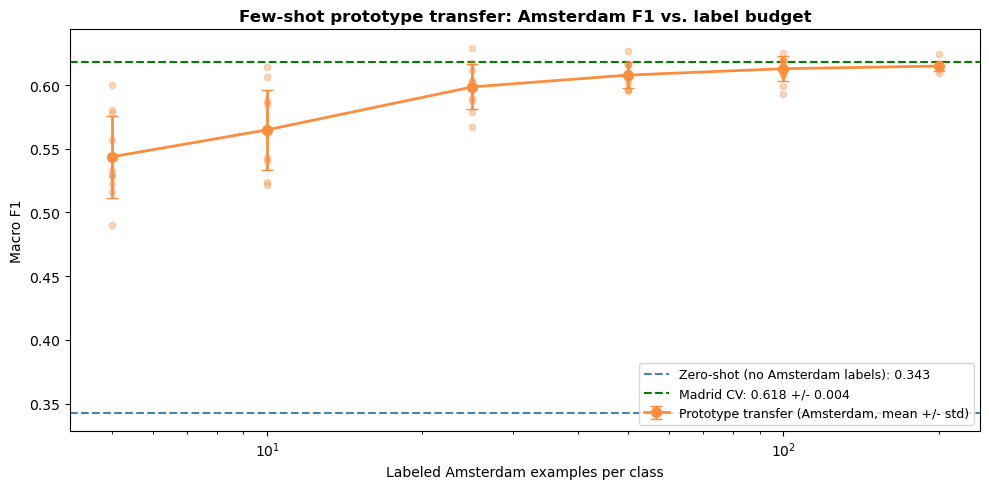

In [54]:
fig, ax = plt.subplots(figsize=(10, 5))

ns    = SHOTS_PER_CLASS
means = [np.mean(proto_results[n]) for n in ns]
stds  = [np.std(proto_results[n])  for n in ns]

# Individual trial scatter
for n in ns:
    ax.scatter([n] * N_TRIALS, proto_results[n],
               color='#fd8d3c', alpha=0.35, s=20, zorder=3)

# Mean + error band
ax.errorbar(ns, means, yerr=stds, fmt='o-', color='#fd8d3c',
            linewidth=2, markersize=7, capsize=4,
            label='Prototype transfer (Amsterdam, mean +/- std)')

# Baselines
ax.axhline(f1_zero, color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Zero-shot (no Amsterdam labels): {f1_zero:.3f}')
ax.axhline(np.mean(fold_f1), color='green', linestyle='--', linewidth=1.5,
           label=f'Madrid CV: {np.mean(fold_f1):.3f} +/- {np.std(fold_f1):.3f}')

ax.set_xlabel('Labeled Amsterdam examples per class')
ax.set_ylabel('Macro F1')
ax.set_xscale('log')
ax.set_title('Few-shot prototype transfer: Amsterdam F1 vs. label budget',
             fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()


The graph  shows that even with 5 examples per class, a huge boost in accuracy is seen compared to the zero-shot model. As few as 25 samples per class increases by an additional 10%, and 100 samples per class is sufficient to clearly establish the class centers, with additional samples bringing only marginal improvement.

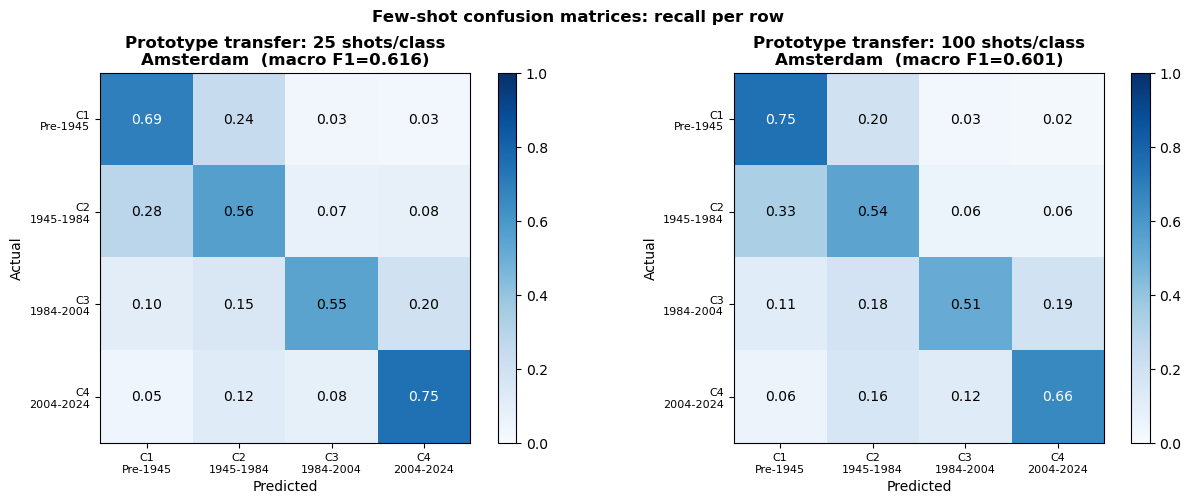

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
rng_cm = np.random.default_rng(42)

for ax, n_shots in zip(axes, [25, 100]):
    support_idx = []
    for cls in classes_ams:
        cls_idx = np.where(y_amsterdam == cls)[0]
        chosen  = rng_cm.choice(cls_idx, min(n_shots, len(cls_idx)), replace=False)
        support_idx.extend(chosen.tolist())

    support_idx = np.array(support_idx)
    query_mask  = np.ones(len(y_amsterdam), dtype=bool)
    query_mask[support_idx] = False

    y_pred_shot = prototype_predict(
        X_amsterdam[support_idx], y_amsterdam[support_idx],
        X_amsterdam[query_mask]
    )
    y_true_q = y_amsterdam[query_mask]

    cm_shot  = confusion_matrix(y_true_q, y_pred_shot, labels=classes_ams)
    cm_snorm = cm_shot.astype(float) / cm_shot.sum(axis=1, keepdims=True)
    f1_shot  = f1_score(y_true_q, y_pred_shot, average='macro', zero_division=0)

    im = ax.imshow(cm_snorm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(xlbls_ams))); ax.set_xticklabels(xlbls_ams, fontsize=8)
    ax.set_yticks(range(len(xlbls_ams))); ax.set_yticklabels(xlbls_ams, fontsize=8)
    for i in range(len(xlbls_ams)):
        for j in range(len(xlbls_ams)):
            v = cm_snorm[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                    color='white' if v > 0.6 else 'black')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Prototype transfer: {n_shots} shots/class\n'
                 f'Amsterdam  (macro F1={f1_shot:.3f})', fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.suptitle('Few-shot confusion matrices: recall per row', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


The recall performance for Amsterdam just about matches (and for some classes exceeds!) the recall obtained for Madrid.

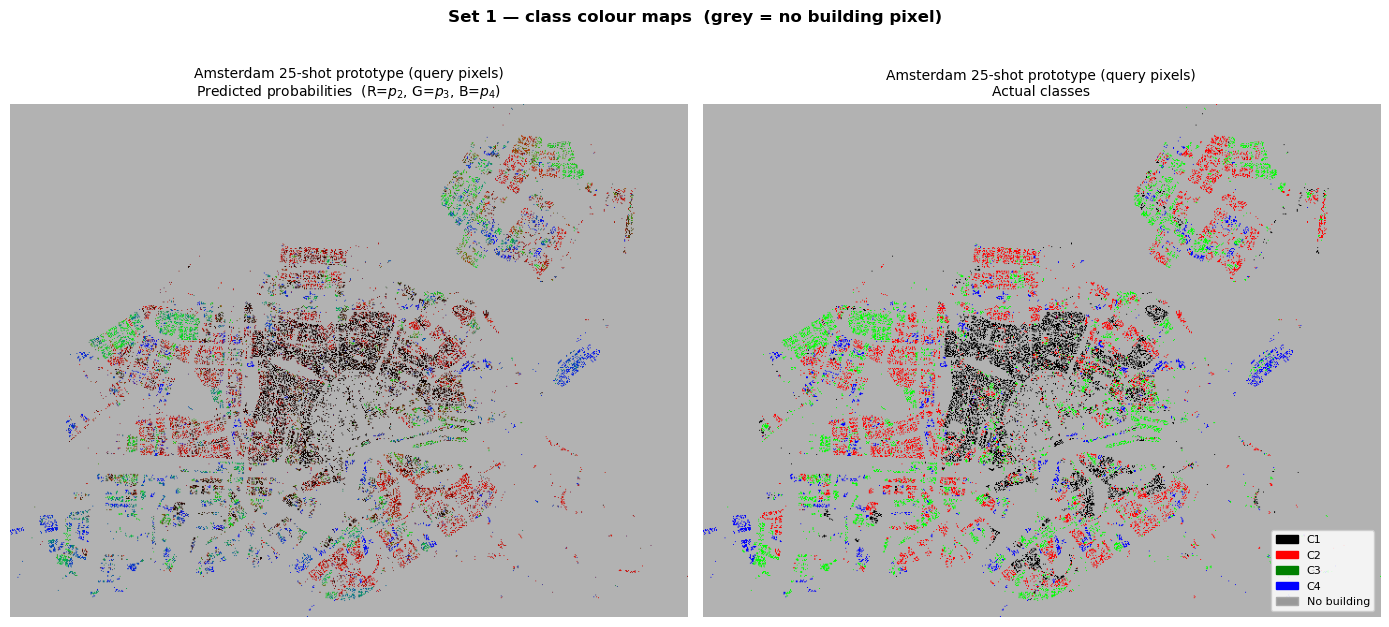

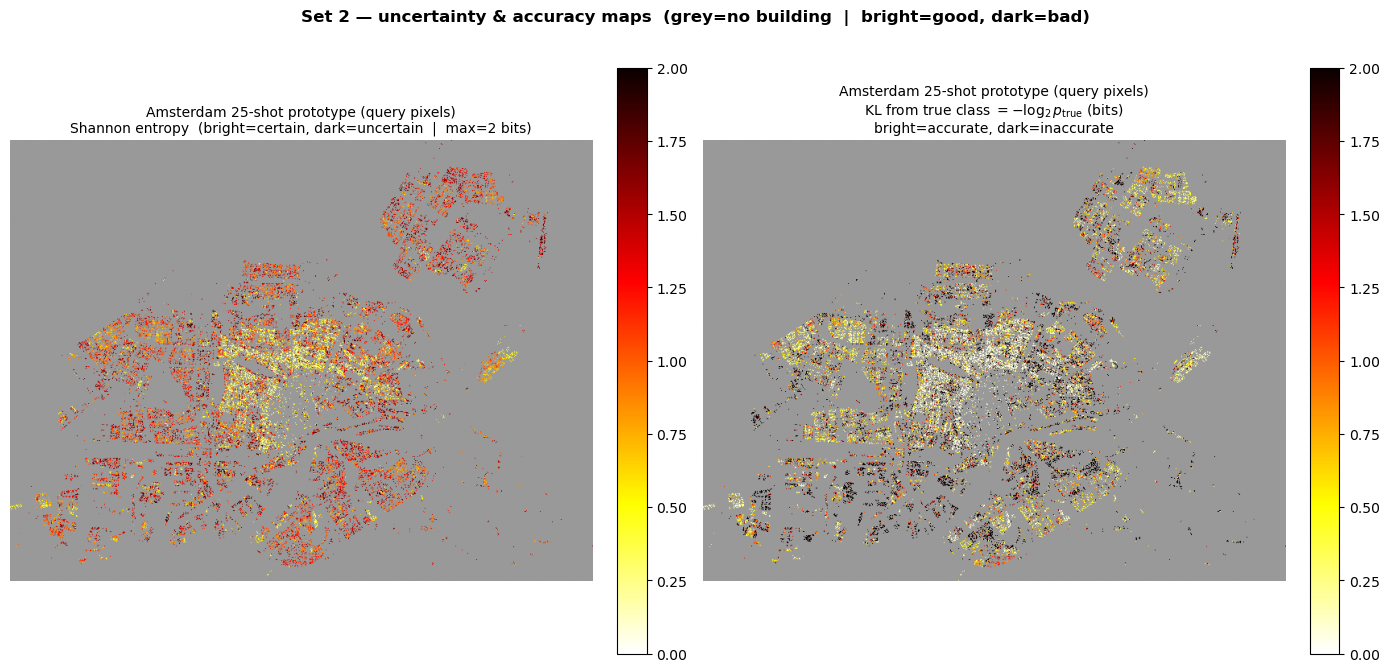

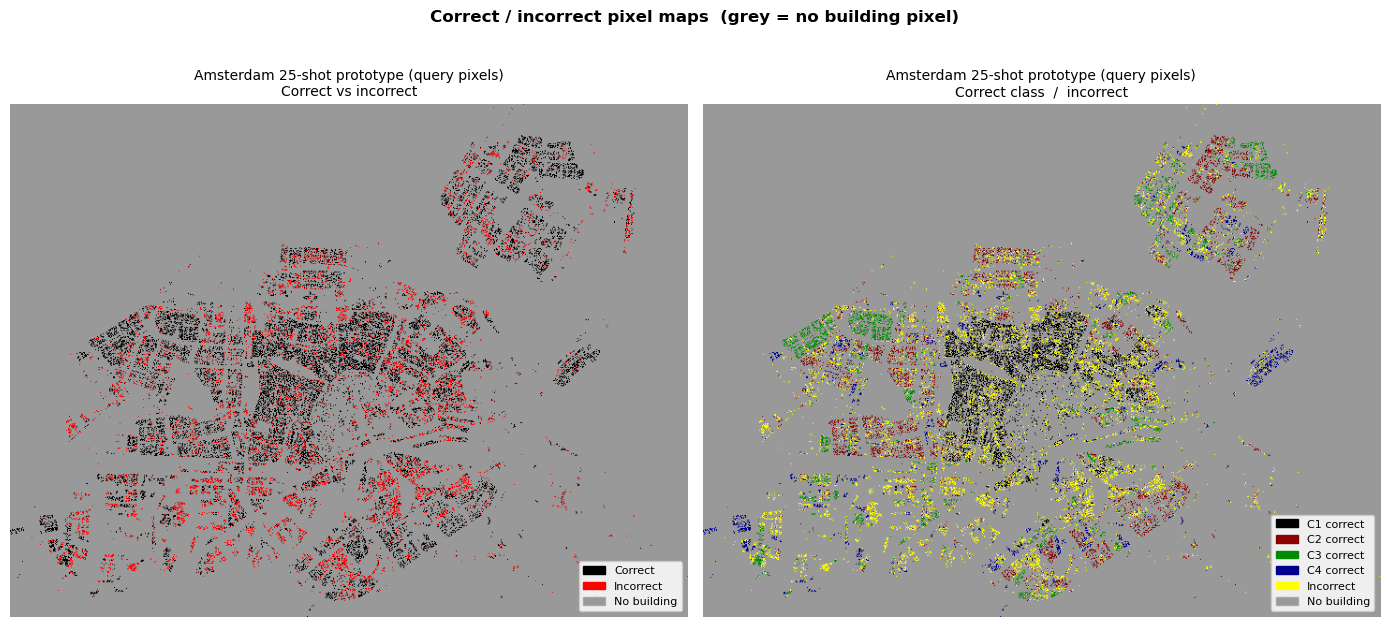

In [56]:
def prototype_predict_proba(X_support, y_support, X_query):
    """Soft class probabilities via softmax of negative L2 distances to prototypes."""
    classes    = np.unique(y_support)
    prototypes = np.stack([X_support[y_support == c].mean(axis=0) for c in classes])
    dists      = np.linalg.norm(X_query[:, None, :] - prototypes[None, :, :], axis=2)
    neg_d      = -dists
    neg_d     -= neg_d.max(axis=1, keepdims=True)
    exp_d      = np.exp(neg_d)
    return classes, exp_d / exp_d.sum(axis=1, keepdims=True)


# Reproduce the exact 25-shot split used in nb4-few-cm (same seed, same first 4 draws)
rng_25      = np.random.default_rng(42)
n_shots_25  = 25
support_idx_25 = []
for cls in classes_ams:
    cls_idx = np.where(y_amsterdam == cls)[0]
    chosen  = rng_25.choice(cls_idx, min(n_shots_25, len(cls_idx)), replace=False)
    support_idx_25.extend(chosen.tolist())
support_idx_25 = np.array(support_idx_25)
query_mask_25  = np.ones(len(y_amsterdam), dtype=bool)
query_mask_25[support_idx_25] = False

X_sup_25    = X_amsterdam[support_idx_25]
y_sup_25    = y_amsterdam[support_idx_25]
X_qry_25    = X_amsterdam[query_mask_25]
y_qry_25    = y_amsterdam[query_mask_25]
pids_qry_25 = pixel_ids_amsterdam[query_mask_25]

_, proba_25 = prototype_predict_proba(X_sup_25, y_sup_25, X_qry_25)
y_pred_25   = prototype_predict(X_sup_25, y_sup_25, X_qry_25)

spatial_uncertainty_plots(pids_qry_25, proba_25, y_qry_25,
                          title_prefix='Amsterdam 25-shot prototype (query pixels)')
spatial_accuracy_plots(pids_qry_25, y_qry_25, y_pred_25,
                       title_prefix='Amsterdam 25-shot prototype (query pixels)')


As with Madrid, the model is identifying most local areas where each specific classes predominates. 

---

## 4.8 Summary

**Madrid cross-validation** (5-fold, with error bars) gives the headline performance
estimate. Error bars reveal how stable the estimate is — tight bars mean the result
is reliable; wide bars mean more folds or data are needed.

**Zero-shot transfer** to Amsterdam shows the raw domain gap: how much performance
degrades when moving to a city the model has never seen. A large gap (>0.1 macro F1)
suggests the feature space does not transfer perfectly, which motivates the few-shot step.

**Few-shot prototype transfer** closes the gap progressively as more Amsterdam labels
are added. The prototype classifier is the simplest form of metric learning inference:
- With very few labels (5-10 per class) it may already improve over zero-shot.
- With 100-200 labels per class the gap to the Madrid CV score should largely close.

### Ideas for improvement

(Note these ideas are generated by Claude, and are not guaranteed.  I didn't check them carefully.  Do your own brainstorming!)

**Better feature representation (higher leverage)**
- Per-decade statistics instead of two fixed periods
- Slope of linear trend per band (captures systematic change over time)
- Year of maximum/minimum reflectance per band
- Changepoint detection features: year of largest single-year jump

**Better metric learning**
- Learn an explicit embedding with triplet loss (neural network)
- Use the Madrid-trained RF leaf node assignments as a kernel embedding
  (`rf.apply()` returns leaf IDs; co-occurrence rate is a natural similarity)
- Domain-adversarial training: penalise features that predict city identity

**Better few-shot transfer**
- Fine-tune on Amsterdam labels rather than using prototypes
- Use the Amsterdam unlabelled data for self-training (pseudo-labels from zero-shot)